<a href="https://colab.research.google.com/github/Mohamed-ktari/Advanced-machine-learning-/blob/main/TP1_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP: Machine Learning (SIA_3611)

## TP3: Clustering (4h)

In machine learning, clustering is related to unsupervised learning approaches in which the algorithm fits from the distribution of given data. The main advantage of such methods is detection without a priori of patterns, sorting data and detecting outliers.

The given dataset is a combination of a dataset produced by the World Health Organization and the location of countries. It pooled the evolution of 23 features for 15 years among numerous countries. One of the goals of this TP3 is to detect continents and subcontinents.

**Objectives:**
- Visualize spatial datasets
- Apply K-Means and GMM on spatial datasets
- Normalize the datasets
- Propose a methodology to detect specific pools of data
- Evaluate the computed clustering


## STEP 1: Spatial datasets and first clusters



The first step is visualizing the mercator projection.

**TO DO 1.1**

Execute the following cells

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors

df = pd.read_csv("data/Life_Expectancy_Data.csv")
df = df.dropna()
df.info()

df1 = df[(df.Year == 2013)]

<class 'pandas.core.frame.DataFrame'>
Index: 1649 entries, 0 to 2937
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          1649 non-null   object 
 1   Longitude                        1649 non-null   float64
 2   Latitude                         1649 non-null   float64
 3   Continent                        1649 non-null   object 
 4   Year                             1649 non-null   int64  
 5   Status                           1649 non-null   object 
 6   Life_expectancy                  1649 non-null   float64
 7   Adult_mortality                  1649 non-null   float64
 8   Infant_deaths                    1649 non-null   int64  
 9   Alcohol                          1649 non-null   float64
 10  Percentage_expenditure           1649 non-null   float64
 11  Hepatitis_B                      1649 non-null   float64
 12  Measles                  

/tmp/ipykernel_590/297642897.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_Y = df_Status.replace(['Africa', 'Asia', 'Europe', 'North America', 'South America', 'Seven seas', 'Oceania'], [0, 1, 2, 3, 4, 5, 6])


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

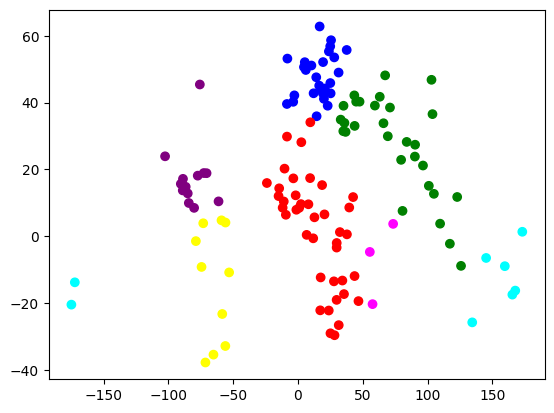

In [4]:
df_X = df1[['Longitude', 'Latitude']]
df_Status = df1[['Continent']]

df_Y = df_Status.replace(['Africa', 'Asia', 'Europe', 'North America', 'South America', 'Seven seas', 'Oceania'], [0, 1, 2, 3, 4, 5, 6])
np_Y = df_Y.to_numpy()
np_Y = np_Y.reshape((np_Y.shape[0],))

np1 = df_X.to_numpy()
plt.scatter(np1[:,0], np1[:,1], c=np_Y, cmap=matplotlib.colors.ListedColormap(['red', 'green', 'blue', 'purple', 'yellow', 'magenta', 'cyan']))
plt

**QUESTION 1**

Identify each class with the plot colors.
### How the Mapping Works
1. **Label Encoding:** `df_Status.replace(...)` maps each continent name to an integer index from `0` to `6` in sequential order.
2. **Color Assignment:** `ListedColormap` assigns the list of colors in matching order: index `0` corresponds to `red`, index `1` to `green`, up to index `6` which corresponds to `cyan`.

| Class (Continent) | Encoded Value | Plot Color |
| :--- | :---: | :--- |
| **Africa** | `0` | **Red** |
| **Asia** | `1` | **Green** |
| **Europe** | `2` | **Blue** |
| **North America** | `3` | **Purple** |
| **South America** | `4` | **Yellow** |
| **Seven seas** | `5` | **Magenta** |
| **Oceania** | `6` | **Cyan** |


What do the coordinates correspond to?


In the code we defined `df_X = df1[['Longitude', 'Latitude']]` which interprets as following :

Longitude ($X$-axis): Represents the horizontal position (East/West), ranging from $-180^\circ$ to $+180^\circ$.\
Latitude ($Y$-axis): Represents the vertical position (North/South), ranging from $-90^\circ$ to $+90^\circ$.

**TO DO 1.2**

Execute the following cell


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

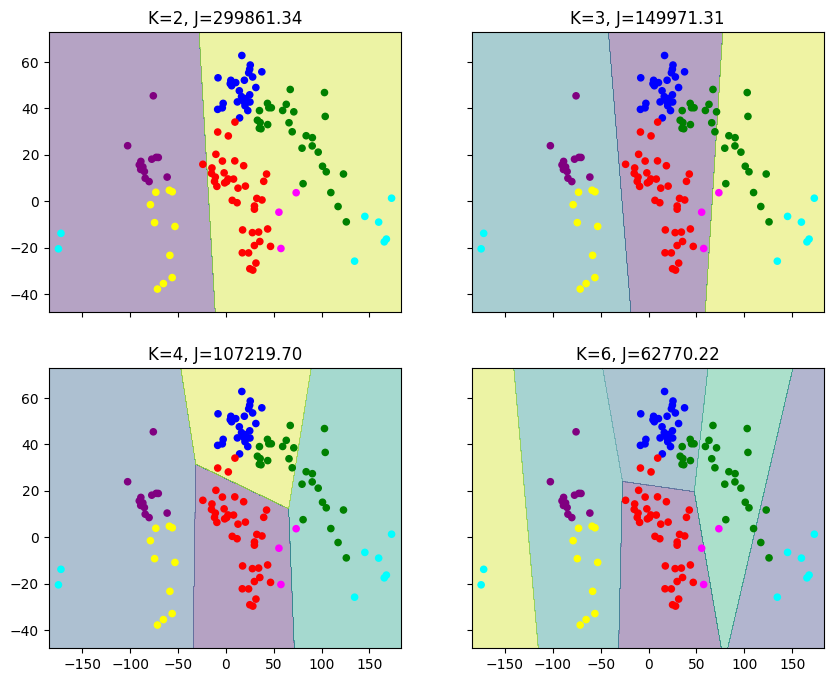

In [7]:
from itertools import product
from sklearn import cluster

x_min, x_max = np1[:, 0].min() - 10, np1[:, 0].max() + 10
y_min, y_max = np1[:, 1].min() - 10, np1[:, 1].max() + 10
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

km2 = cluster.KMeans(n_clusters=2).fit(np1)
km3 = cluster.KMeans(n_clusters=3).fit(np1)
km4 = cluster.KMeans(n_clusters=4).fit(np1)
km6 = cluster.KMeans(n_clusters=6).fit(np1)

f, axarr = plt.subplots(2, 2, sharex='col', sharey='row', figsize=(10, 8))

for idx, km, tt in zip(product([0, 1], [0, 1]),
                        [km2, km3, km4, km6],
                        ["K=2, J=%.2f" % km2.inertia_,
                         "K=3, J=%.2f" % km3.inertia_,
                         "K=4, J=%.2f" % km4.inertia_,
                         "K=6, J=%.2f" % km6.inertia_]):

    Z = km.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.4)
    axarr[idx[0], idx[1]].scatter(np1[:, 0], np1[:, 1], c=np_Y,
                                  s=20, cmap=matplotlib.colors.ListedColormap(['red', 'green', 'blue', 'purple', 'yellow', 'magenta', 'cyan']))
    axarr[idx[0], idx[1]].set_title(tt)

plt

**QUESTION 2**

How can Inertia be used to compare clusters?\

Inertia is the Sum of Squared Errors (SSE) or the sum of squared distances of samples to their closest cluster center.

**Comparing different $K$ values (Same Model)**: You plot Inertia vs. $K$ (the Elbow Method). As $K$ increases, inertia strictly decreases because cluster radii shrink. The "elbow" on the plot indicates the $K$ where adding more clusters no longer significantly improves cluster compactness.\

**Comparing different runs/initializations (Same $K$)**: Because $K$-Means is sensitive to random centroid initialization, you run the algorithm multiple times for the same $K$ and select the model with the lowest overall inertia, as it represents the tightest grouping.


Can you propose a better metric for spatial datasets?\
Inertia relies on flat Euclidean distance ($d = \sqrt{\Delta x^2 + \Delta y^2}$), which distorts real-world geographical relationships.\
Better metric for spatial data:\
**Silhouette Index (using Spatial Distance)**: Measures how similar a point is to its own cluster compared to other clusters, calculated using Haversine distance. Values range from $-1$ to $+1$; higher values indicate well-separated spatial clusters.\

Although the $K$-Means model is trained in an unsupervised manner using only $df\_X$ (Longitude, Latitude), our dataset contains known ground-truth continent labels ($df\_Status$). To evaluate how accurately the unsupervised clusters reconstruct real-world continent boundaries, we can use external validation metric:
**Adjusted Rand Index (ARI)**: Computes the agreement between $K$-Means cluster assignments and ground-truth continent labels (np_Y), correcting for chance allocations. Values range from $-1$ to $+1$, where $+1$ represents a perfect structural alignment with actual continents.\



Which is the main problem with the mercator representation for continent detection?\

The main problem is extreme area distortion and non-linear distance warping at high latitudes:\
**Distance Distortion**: On a Mercator (or raw equirectangular Longitude/Latitude) grid, $1^\circ$ of longitude near the Equator spans roughly $111\text{ km}$, but $1^\circ$ of longitude near the poles approaches $0\text{ km}$.\
**Impact on K-Means**: $K$-Means assumes a uniform 2D Euclidean grid where $1$ unit along the $X$-axis equals $1$ unit along the $Y$-axis everywhere. On a Mercator layout, spherical distance is distorted, causing $K$-Means to measure distances incorrectly near polar regions (e.g., exaggerating distance near Greenland or Antarctica while squeezing regions near the Equator).\
**Shape & Area Inflation**: High-latitude continents (Europe, North America, Antarctica) appear far larger than they actually are relative to equatorial continents (Africa, South America), causing centroid placement to skew heavily toward high-latitude points.







## STEP 2: Spatial dataset normalization

**TO CODE 2.1**

Displace the origin of longitude to 30° east.

In [8]:
df1 = df1.copy()
df1['Longitude'] = ((df1['Longitude'] - 30 + 180) % 360) - 180

**QUESTION 3**

What are the advantages of this normalization?

### Advantages of Displacing the Longitude Origin to 30° East

* **Eliminates Boundary Discontinuities:** Shifting the origin moves the artificial $(\pm180^\circ$) coordinate boundary (International Date Line) out of active landmasses into the empty Pacific Ocean, preventing physically adjacent points from being treated as $(360^\circ$) apart.
* **Prevents Centroid Distortion:** \(K\)-Means calculates centroids using arithmetic means. By avoiding the $(\pm180^\circ$) wrap-around seam across continents, it stops centroids from erroneously pulling to the opposite side of the globe.
* **Preserves Spatial Continuity:** It ensures landmasses like Asia, Oceania, and easternmost Russia remain contiguous single clusters rather than being artificially split into separate numerical extremes.
* **Optimizes Data Centering:** It recenters the coordinate system around the Afro-Eurasian landmass matrix, creating a more balanced feature distribution for distance-based clustering algorithms.

**TO CODE 2.2**

Apply KMeans to the new normalized dataset.

/tmp/ipykernel_590/2802220537.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_Y = df1[['Continent']].replace(


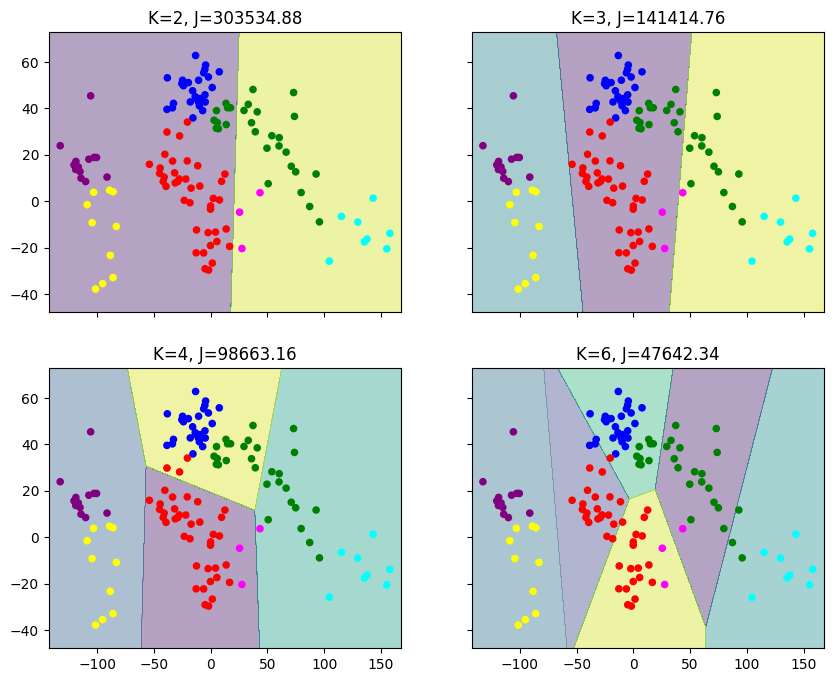

In [9]:
from itertools import product
from sklearn import cluster

# Rebuild arrays from the shifted df1
df_X = df1[['Longitude', 'Latitude']]
np1 = df_X.to_numpy()

df_Y = df1[['Continent']].replace(
    ['Africa', 'Asia', 'Europe', 'North America', 'South America', 'Seven seas', 'Oceania'],
    [0, 1, 2, 3, 4, 5, 6])
np_Y = df_Y.to_numpy().reshape(-1)

cmap_cont = matplotlib.colors.ListedColormap(['red', 'green', 'blue', 'purple', 'yellow', 'magenta', 'cyan'])

# Meshgrid recomputed from the new range
x_min, x_max = np1[:, 0].min() - 10, np1[:, 0].max() + 10
y_min, y_max = np1[:, 1].min() - 10, np1[:, 1].max() + 10
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# KMeans with fixed seed for reproducible results
Ks = [2, 3, 4, 6]
kms = [cluster.KMeans(n_clusters=k, n_init=10, random_state=0).fit(np1) for k in Ks]

f, axarr = plt.subplots(2, 2, sharex='col', sharey='row', figsize=(10, 8))

for idx, km, k in zip(product([0, 1], [0, 1]), kms, Ks):
    Z = km.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax = axarr[idx[0], idx[1]]
    ax.contourf(xx, yy, Z, alpha=0.4)
    ax.scatter(np1[:, 0], np1[:, 1], c=np_Y, s=20, cmap=cmap_cont)
    ax.set_title("K=%d, J=%.2f" % (k, km.inertia_))

plt.show()

Gaussian Mixture Model is a clustering method allowing soft boundaries.

This method can be used through a [sklearn function](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html "Gaussian Mixture")

**TO CODE 2.3**

Apply GMM to the normalized dataset.

You have to test 3 conditions:

- GMM with default parameters for 2, 3, 4 and 6 components

- GMM with diagonal covariance matrix for 2, 3, 4 and 6 components

- GMM with random initialization for 2, 3, 4 and 6 components

In [10]:
from sklearn.mixture import GaussianMixture
from itertools import product

Ks = [2, 3, 4, 6]

def plot_gmm(title, **gmm_params):
    gmms = [GaussianMixture(n_components=k, random_state=0, **gmm_params).fit(np1) for k in Ks]
    f, axarr = plt.subplots(2, 2, sharex='col', sharey='row', figsize=(10, 8))
    for idx, gmm, k in zip(product([0, 1], [0, 1]), gmms, Ks):
        Z = gmm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax = axarr[idx[0], idx[1]]
        ax.contourf(xx, yy, Z, alpha=0.4)
        ax.scatter(np1[:, 0], np1[:, 1], c=np_Y, s=20, cmap=cmap_cont)
        ax.set_title("K=%d, BIC=%.0f" % (k, gmm.bic(np1)))
    f.suptitle(title)
    plt.show()
    return gmms



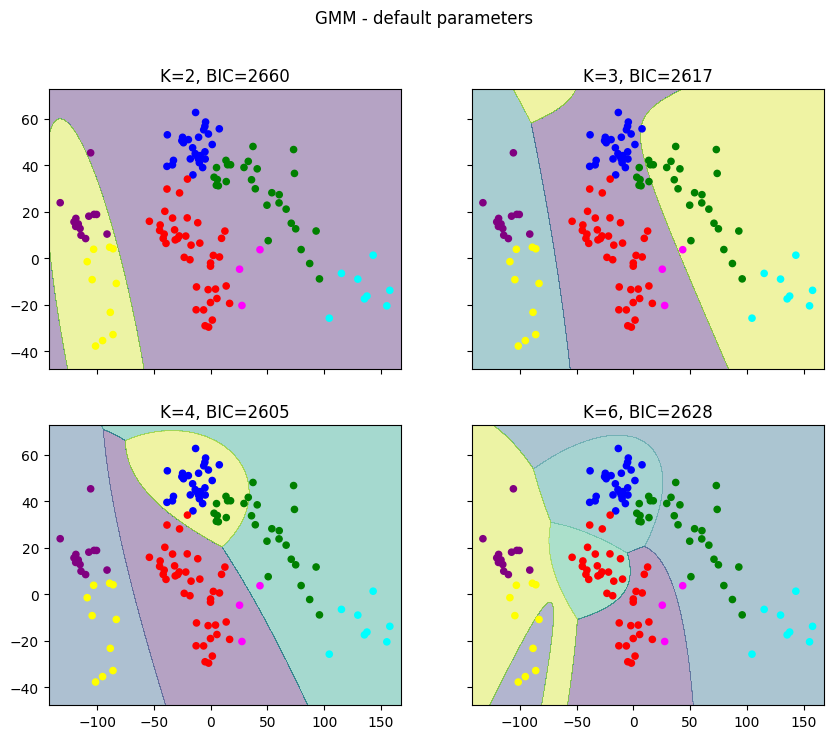

In [11]:
# 1) Default parameters (full covariance, kmeans init)
gmm_default = plot_gmm("GMM - default parameters")

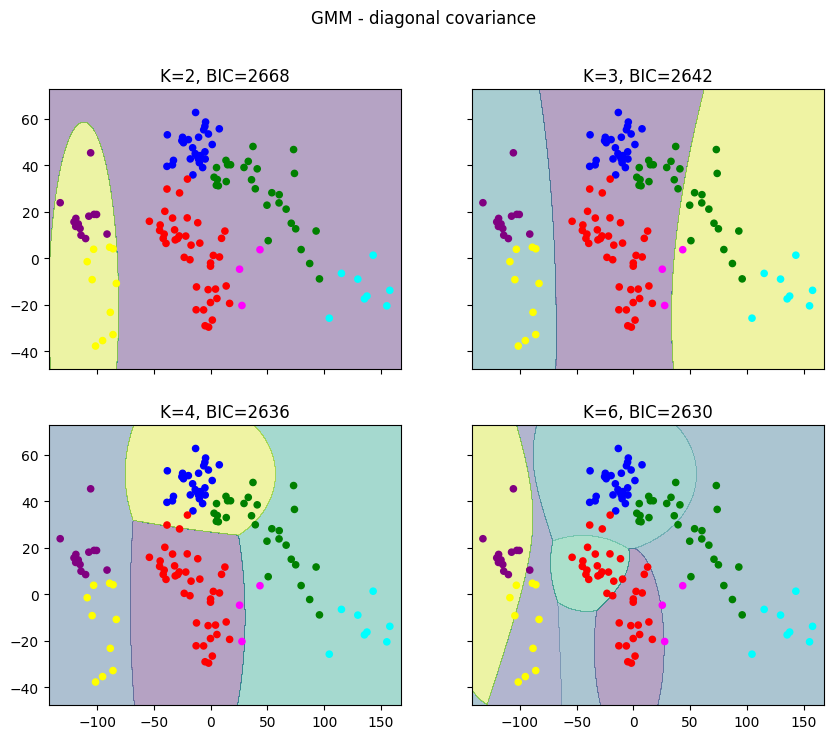

In [12]:
# 2) Diagonal covariance matrix
gmm_diag = plot_gmm("GMM - diagonal covariance", covariance_type='diag')

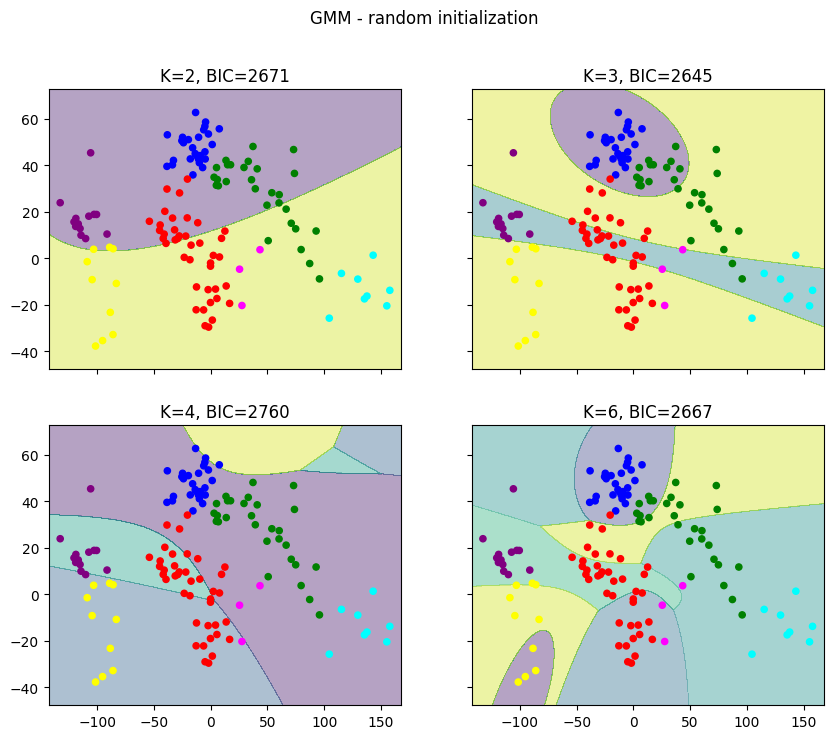

In [13]:
# 3) Random initialization
gmm_random = plot_gmm("GMM - random initialization", init_params='random')

**QUESTION 4**

Which is the best method to detect continents?

For this method, what would be the probability to find a country in the coordinates [-50, -40]? What methodology can you think of to detect unpopulated oceans?

**BONUS**

Rather than applying the previous longitudinal normalization in the mercator projected data and applying k-means, we could directly apply k-means on the unit-sphere representing the earth. The cosine similarity thus becomes a more suitable similarity measure than the euclidean distance.

Apply a KMeans with cosine similarity on the sphere instead of the previously tested euclidean distance in the plane.

In [14]:
df_orig = df[df.Year == 2013]          # original longitudes, not shifted
lon = np.radians(df_orig['Longitude'].to_numpy())
lat = np.radians(df_orig['Latitude'].to_numpy())

X3 = np.c_[np.cos(lat) * np.cos(lon),
           np.cos(lat) * np.sin(lon),
           np.sin(lat)]                 # shape (n, 3), each row has norm 1

In [15]:
def spherical_kmeans(X, k, n_init=10, max_iter=100, seed=0):
    rng = np.random.RandomState(seed)
    best = None
    for _ in range(n_init):
        C = X[rng.choice(len(X), k, replace=False)]        # init on data points
        for _ in range(max_iter):
            labels = np.argmax(X @ C.T, axis=1)            # max cosine similarity
            C_new = np.array([X[labels == j].sum(axis=0) if np.any(labels == j) else C[j]
                              for j in range(k)])
            C_new /= np.linalg.norm(C_new, axis=1, keepdims=True)   # back on the sphere
            if np.allclose(C, C_new):
                break
            C = C_new
        labels = np.argmax(X @ C.T, axis=1)
        J = np.sum(1 - np.sum(X * C[labels], axis=1))      # total cosine distance
        if best is None or J < best[0]:
            best = (J, C, labels)
    return best   # (J, centers, labels)

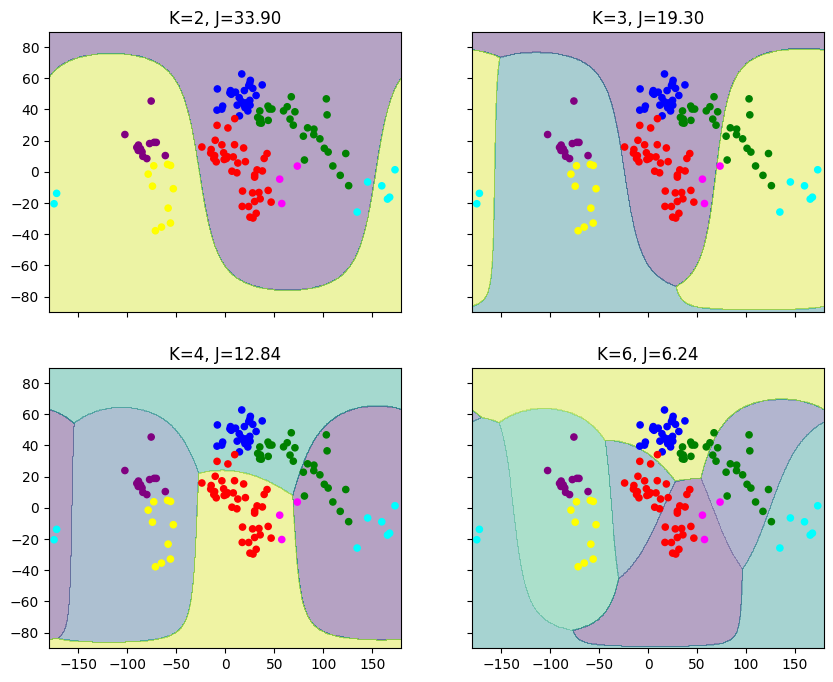

In [16]:
Ks = [2, 3, 4, 6]

# grid of the whole globe, converted to the sphere to predict
glon, glat = np.meshgrid(np.arange(-180, 180, 0.5), np.arange(-90, 90, 0.5))
gl, gt = np.radians(glon.ravel()), np.radians(glat.ravel())
G3 = np.c_[np.cos(gt) * np.cos(gl), np.cos(gt) * np.sin(gl), np.sin(gt)]

lon_deg = df_orig['Longitude'].to_numpy()
lat_deg = df_orig['Latitude'].to_numpy()

f, axarr = plt.subplots(2, 2, sharex='col', sharey='row', figsize=(10, 8))
for idx, k in zip(product([0, 1], [0, 1]), Ks):
    J, C, labels = spherical_kmeans(X3, k)
    Z = np.argmax(G3 @ C.T, axis=1).reshape(glon.shape)
    ax = axarr[idx[0], idx[1]]
    ax.contourf(glon, glat, Z, alpha=0.4)
    ax.scatter(lon_deg, lat_deg, c=np_Y, s=20, cmap=cmap_cont)
    ax.set_title("K=%d, J=%.2f" % (k, J))
plt.show()

## STEP 3: Detection of caribbean island

**TO CODE 3.1**

Isolate the North and South American continents.

In [19]:
df_am = df[(df.Year == 2013) &
           (df.Continent.isin(['North America', 'South America']))].copy()

print(df_am.Continent.value_counts())

# Features: planar coordinates (lon, lat)
np_am = df_am[['Longitude', 'Latitude']].to_numpy()

# Labels re-encoded as 0 = North America, 1 = South America
np_Y_am = (df_am['Continent'] == 'South America').astype(int).to_numpy()

Continent
North America    13
South America    10
Name: count, dtype: int64


**TO CODE 3.2**

Propose a methodology to create a cluster including caribbean independent nations.

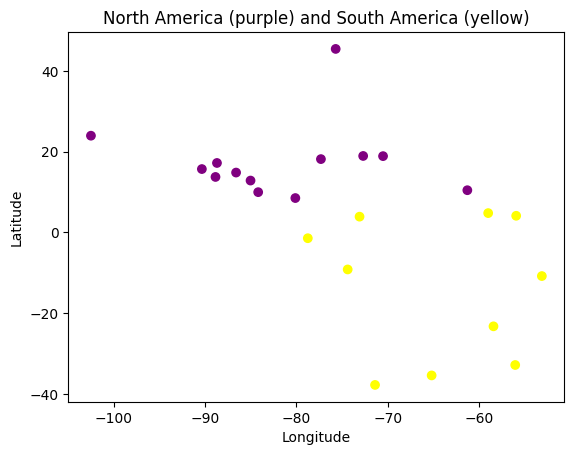

In [20]:
# Unit-sphere version, for the cosine-similarity K-Means
lon = np.radians(df_am['Longitude'].to_numpy())
lat = np.radians(df_am['Latitude'].to_numpy())
X3_am = np.c_[np.cos(lat) * np.cos(lon),
              np.cos(lat) * np.sin(lon),
              np.sin(lat)]

# Check
cmap_am = matplotlib.colors.ListedColormap(['purple', 'yellow'])
plt.scatter(np_am[:, 0], np_am[:, 1], c=np_Y_am, cmap=cmap_am)
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('North America (purple) and South America (yellow)')
plt.show()

In [25]:
from sklearn.mixture import GaussianMixture

caribbean = ['Cuba', 'Jamaica', 'Haiti', 'Dominican Republic', 'Bahamas', 'Barbados',
             'Trinidad and Tobago', 'Antigua and Barbuda', 'Saint Lucia', 'Grenada',
             'Dominica', 'Saint Vincent and the Grenadines', 'Saint Kitts and Nevis']

print(df_am[df_am.Country.isin(caribbean)].Country.tolist())   # which ones are actually in the data


['Dominican Republic', 'Haiti', 'Jamaica', 'Trinidad and Tobago']


In [26]:
for k in [3, 4, 5]:
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=10, random_state=0).fit(np_am)
    df_am['cluster'] = gmm.predict(np_am)
    print(k, "BIC=%.0f" % gmm.bic(np_am))
    print(df_am.groupby('cluster').Country.apply(list), "\n")

3 BIC=377
cluster
0    [Belize, Colombia, Costa Rica, Dominican Repub...
1    [Argentina, Brazil, Chile, Paraguay, Peru, Uru...
2                                             [Canada]
Name: Country, dtype: object 

4 BIC=367
cluster
0    [Canada, Colombia, Dominican Republic, Ecuador...
1                          [Argentina, Chile, Uruguay]
2                                   [Brazil, Paraguay]
3    [Belize, Costa Rica, El Salvador, Guatemala, G...
Name: Country, dtype: object 

5 BIC=367
cluster
0    [Belize, Colombia, Costa Rica, El Salvador, Gu...
1                [Argentina, Chile, Paraguay, Uruguay]
2                 [Dominican Republic, Haiti, Jamaica]
3    [Brazil, Ecuador, Guyana, Peru, Suriname, Trin...
4                                             [Canada]
Name: Country, dtype: object 



Cluster 0: Belize, Colombia, Costa Rica, El Salvador, Guatemala, Honduras, Mexico, Nicaragua, Panama

Cluster 1: Argentina, Chile, Paraguay, Uruguay

Cluster 2: Dominican Republic, Haiti, Jamaica

Cluster 3: Brazil, Ecuador, Guyana, Peru, Suriname, Trinidad and Tobago

Cluster 4: Canada



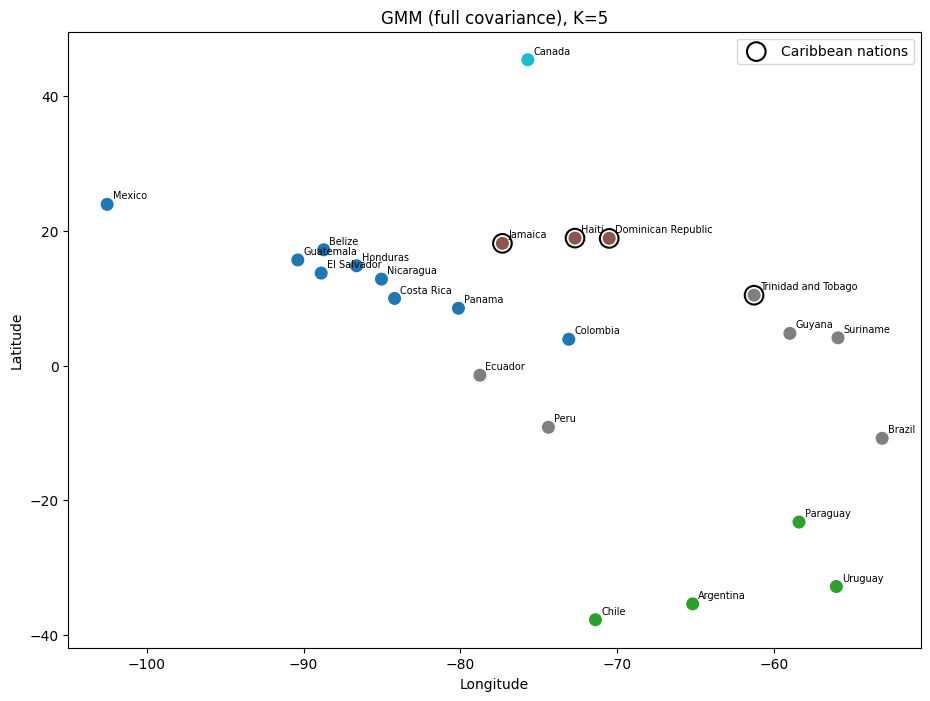

                       0    1    2    3    4
Country                                     
Dominican Republic   0.0  0.0  1.0  0.0  0.0
Haiti                0.0  0.0  1.0  0.0  0.0
Jamaica              0.0  0.0  1.0  0.0  0.0
Trinidad and Tobago  0.0  0.0  0.0  1.0  0.0


In [27]:
K = 5
gmm = GaussianMixture(n_components=K, covariance_type='full', n_init=10, random_state=0).fit(np_am)
df_am['cluster'] = gmm.predict(np_am)

# 1) Readable text output
for c, g in df_am.groupby('cluster'):
    print(f"Cluster {c}: {', '.join(g.Country)}\n")

# 2) Labeled map
caribbean = ['Dominican Republic', 'Haiti', 'Jamaica', 'Trinidad and Tobago']
is_car = df_am.Country.isin(caribbean)

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(df_am.Longitude, df_am.Latitude, c=df_am.cluster, cmap='tab10', s=70)
ax.scatter(df_am.Longitude[is_car], df_am.Latitude[is_car], s=180,
           facecolors='none', edgecolors='black', linewidths=1.5, label='Caribbean nations')
for _, r in df_am.iterrows():
    ax.annotate(r.Country, (r.Longitude, r.Latitude), fontsize=7,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'GMM (full covariance), K={K}')
ax.legend()
plt.show()

# 3) Soft membership of the Caribbean countries
proba = pd.DataFrame(gmm.predict_proba(np_am).round(2), index=df_am.Country)
print(proba.loc[caribbean])

**QUESTION 5**

Which is the outlier of this clustering problem?\
**Methodology:**\
Step1 : Restrict to the Americas.\
Step2 : Fit a full-covariance GMM with several K and compare the BIC.\
Step3 : Take K=5 and identify the cluster containing Haiti, Jamaica and the Dominican Republic.\
**Observations:**
Trinidad and Tobago is misassigned, the sample is small, and Canada is an outlier.

## STEP 4 : Evaluating a cluster

In this section, we try to evaluate the quality of the different clusters computed.

**TO DO 4.1**
Execute the following cells. On the first cell, you can add code to once again displace the longitude by 30° east.

/tmp/ipykernel_590/2842310785.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Longitude'] = ((df1['Longitude'] - 30 + 180) % 360) - 180
/tmp/ipykernel_590/2842310785.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_Y = df_Status.replace(['Africa', 'Asia', 'Europe', 'North America', 'South America', 'Seven seas', 'Oceania'], [0, 1, 2, 3, 4, 5, 6])


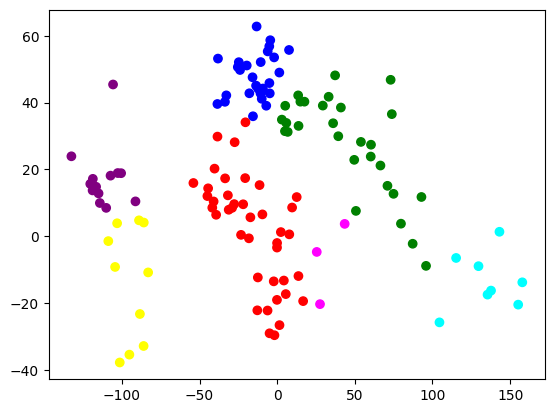

In [28]:
df1 = df[(df.Year == 2013)]
df1['Longitude'] = ((df1['Longitude'] - 30 + 180) % 360) - 180

df_X = df1[['Longitude', 'Latitude']]
df_Status = df1[['Continent']]

df_Y = df_Status.replace(['Africa', 'Asia', 'Europe', 'North America', 'South America', 'Seven seas', 'Oceania'], [0, 1, 2, 3, 4, 5, 6])
np_Y = df_Y.to_numpy()
np_Y = np_Y.reshape((np_Y.shape[0],))

np1 = df_X.to_numpy()
plt.scatter(np1[:,0], np1[:,1], c=np_Y, cmap=matplotlib.colors.ListedColormap(['red', 'green', 'blue', 'purple', 'yellow', 'magenta', 'cyan']))
plt.show()


In [29]:
x_min, x_max = np1[:, 0].min() - 10, np1[:, 0].max() + 10
y_min, y_max = np1[:, 1].min() - 10, np1[:, 1].max() + 10
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

For n_clusters = 3 The average silhouette_score is : 0.5399410318541973


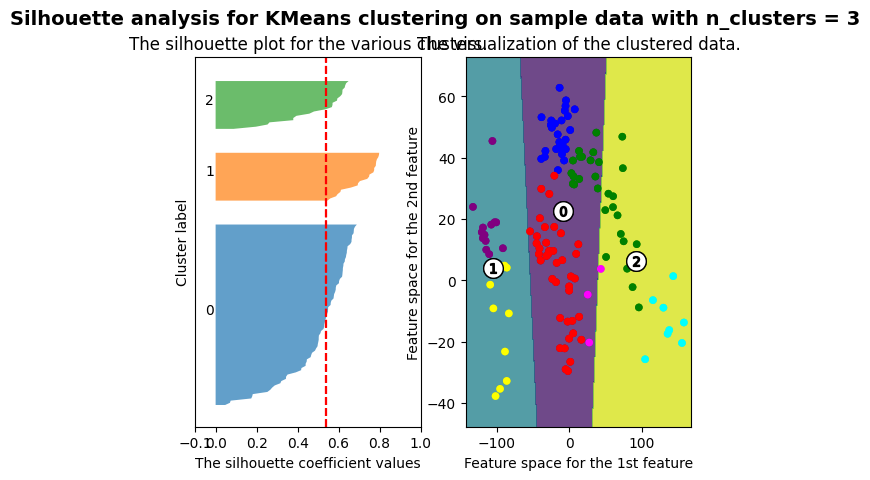

In [30]:
from sklearn.metrics import silhouette_samples, silhouette_score

K = 3

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(np1) + (K + 1) * 10])

km = cluster.KMeans(n_clusters=K, random_state=10)
cluster_labels = km.fit_predict(np1)

silhouette_avg = silhouette_score(np1, cluster_labels)
print("For n_clusters =", K, "The average silhouette_score is :", silhouette_avg)
sample_silhouette_values = silhouette_samples(np1, cluster_labels)

y_lower = 10
for i in range(K):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        alpha=0.7,
    )

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    Z = km.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax2.contourf(xx, yy, Z, alpha=0.4)
    ax2.scatter(np1[:, 0], np1[:, 1], c=np_Y,
                s=20, cmap=matplotlib.colors.ListedColormap(['red', 'green', 'blue', 'purple', 'yellow', 'magenta', 'cyan']))

    # Labeling the clusters
    centers = km.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % K,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

**TO DO 4.2**

Apply the previous code for different values of K (2,3,4 and 6).

For n_clusters = 2 The average silhouette_score is : 0.4500091692627438


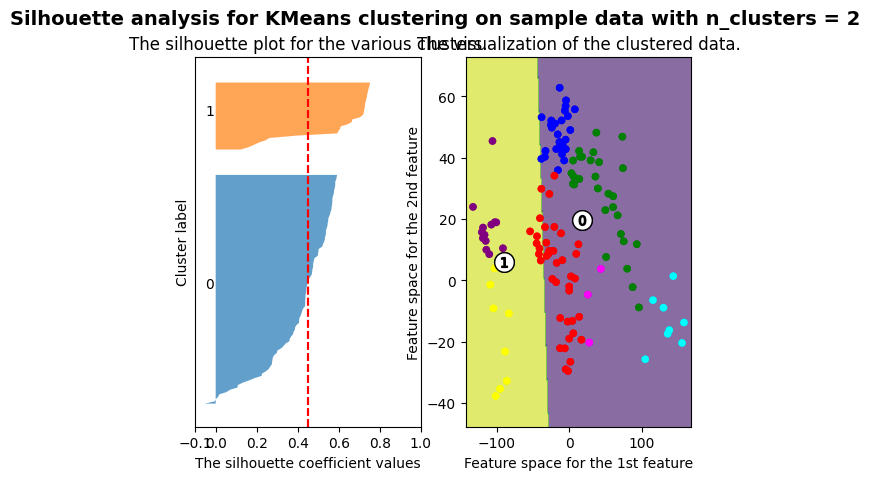

For n_clusters = 3 The average silhouette_score is : 0.5399410318541973


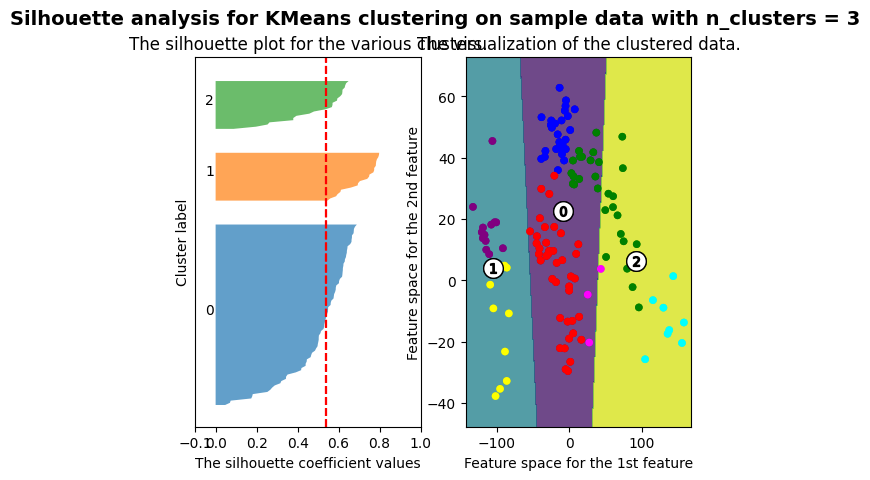

For n_clusters = 4 The average silhouette_score is : 0.4875009627702223


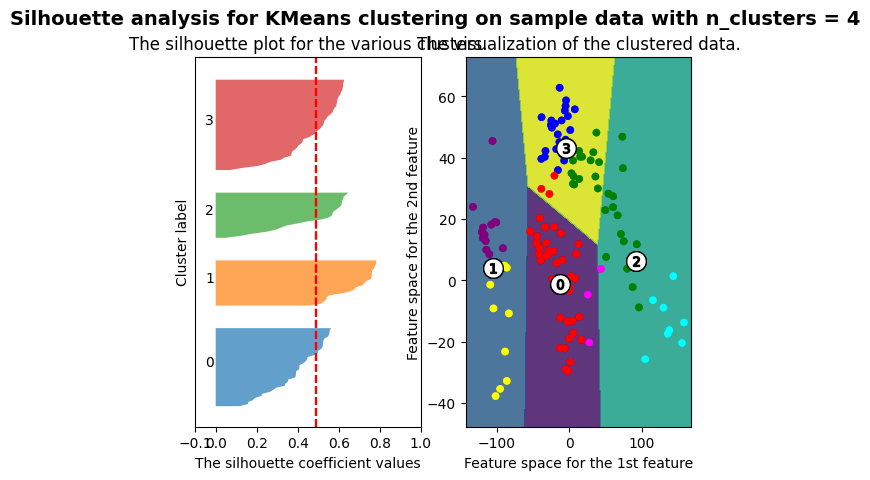

For n_clusters = 6 The average silhouette_score is : 0.5172067215678542


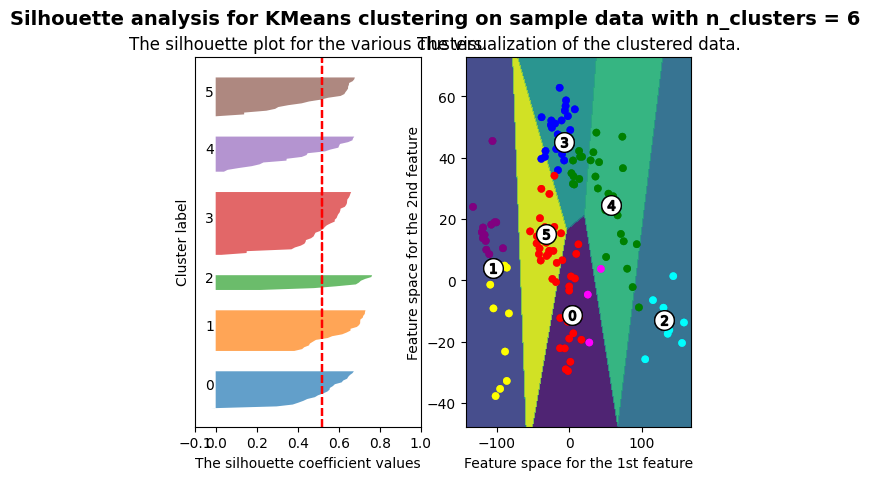

In [31]:
from sklearn.metrics import silhouette_samples, silhouette_score
k_values = [2,3,4,6]
for K in k_values:
  fig, (ax1, ax2) = plt.subplots(1, 2)
  ax1.set_xlim([-0.1, 1])
  ax1.set_ylim([0, len(np1) + (K + 1) * 10])

  km = cluster.KMeans(n_clusters=K, random_state=10)
  cluster_labels = km.fit_predict(np1)

  silhouette_avg = silhouette_score(np1, cluster_labels)
  print("For n_clusters =", K, "The average silhouette_score is :", silhouette_avg)
  sample_silhouette_values = silhouette_samples(np1, cluster_labels)

  y_lower = 10
  for i in range(K):
      ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
      ith_cluster_silhouette_values.sort()

      size_cluster_i = ith_cluster_silhouette_values.shape[0]
      y_upper = y_lower + size_cluster_i

      ax1.fill_betweenx(
          np.arange(y_lower, y_upper),
          0,
          ith_cluster_silhouette_values,
          alpha=0.7,
      )

      ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

      y_lower = y_upper + 10  # 10 for the 0 samples

      ax1.set_title("The silhouette plot for the various clusters.")
      ax1.set_xlabel("The silhouette coefficient values")
      ax1.set_ylabel("Cluster label")

      # The vertical line for average silhouette score of all the values
      ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

      ax1.set_yticks([])  # Clear the yaxis labels / ticks
      ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

      # 2nd Plot showing the actual clusters formed
      Z = km.predict(np.c_[xx.ravel(), yy.ravel()])
      Z = Z.reshape(xx.shape)

      ax2.contourf(xx, yy, Z, alpha=0.4)
      ax2.scatter(np1[:, 0], np1[:, 1], c=np_Y,
                  s=20, cmap=matplotlib.colors.ListedColormap(['red', 'green', 'blue', 'purple', 'yellow', 'magenta', 'cyan']))

      # Labeling the clusters
      centers = km.cluster_centers_
      # Draw white circles at cluster centers
      ax2.scatter(
          centers[:, 0],
          centers[:, 1],
          marker="o",
          c="white",
          alpha=1,
          s=200,
          edgecolor="k",
      )

      for i, c in enumerate(centers):
          ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

      ax2.set_title("The visualization of the clustered data.")
      ax2.set_xlabel("Feature space for the 1st feature")
      ax2.set_ylabel("Feature space for the 2nd feature")

      plt.suptitle(
          "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
          % K,
          fontsize=14,
          fontweight="bold",
      )

  plt.show()

**Question 6**

According to the silhouette score and the silhouette analysis, which is the most relevant value of K ? Justify your response.


**Answer: K=3**.\
 The average silhouette is 0.540 for K=3 and 0.517 for K=6. The K=3 plot shows three thick, well-formed silhouettes, and all three clusters have most of their points above the average line (red dashed with value 0.5). At K=6 the average drops, and clusters 2, 4 and 5 are thin, meaning they are small and barely separated from their neighbors. Cluster 2 (Oceania and the far east, top right of the map) is very thin, so it is a small group carved out of a larger one. the Higher the silhouette average the better so K=3 wins.

**BONUS**

Compute the silhouette score and analyze it for different number of components and parameters of Gaussian Mixture.

In [32]:
def silhouette_gmm(K, title, **gmm_params):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(np1) + (K + 1) * 10])

    gmm = GaussianMixture(n_components=K, random_state=10, **gmm_params)
    cluster_labels = gmm.fit_predict(np1)

    silhouette_avg = silhouette_score(np1, cluster_labels)
    sample_silhouette_values = silhouette_samples(np1, cluster_labels)

    y_lower = 10
    for i in range(K):
        vals = np.sort(sample_silhouette_values[cluster_labels == i])
        size_i = vals.shape[0]
        y_upper = y_lower + size_i
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_i, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_title("Silhouette plot")
    ax1.set_xlabel("Silhouette coefficient")
    ax1.set_ylabel("Cluster label")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    Z = gmm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax2.contourf(xx, yy, Z, alpha=0.4)
    ax2.scatter(np1[:, 0], np1[:, 1], c=np_Y, s=20, cmap=cmap_cont)

    centers = gmm.means_
    ax2.scatter(centers[:, 0], centers[:, 1], marker="o", c="white",
                s=200, edgecolor="k")
    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, s=50, edgecolor="k")
    ax2.set_title("Clusters found")
    ax2.set_xlabel("Longitude")
    ax2.set_ylabel("Latitude")

    plt.suptitle("%s, n_components = %d, mean silhouette = %.3f"
                 % (title, K, silhouette_avg), fontsize=13, fontweight="bold")
    plt.show()
    return silhouette_avg, gmm.bic(np1)


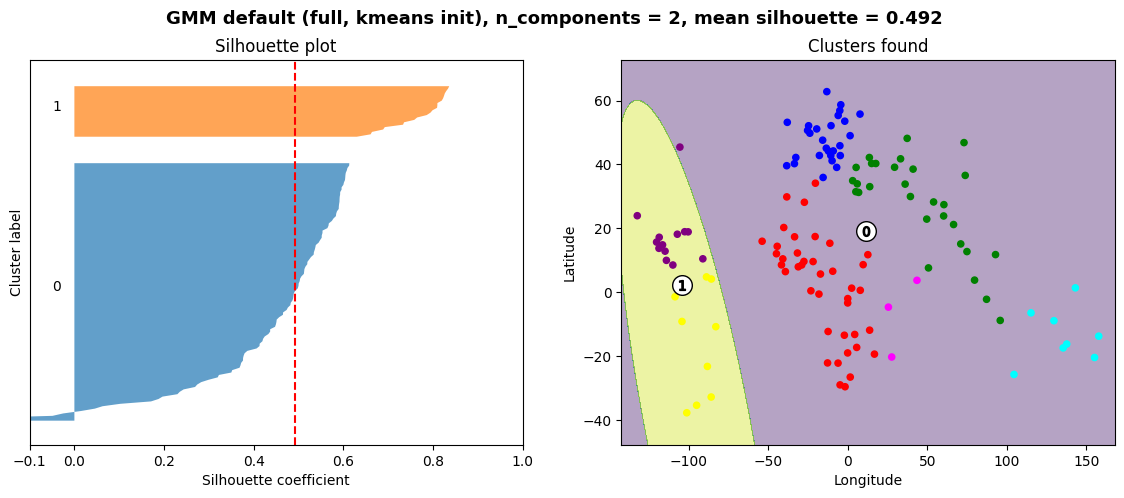

GMM default (full, kmeans init)     K=2  silhouette=0.492  BIC=2660


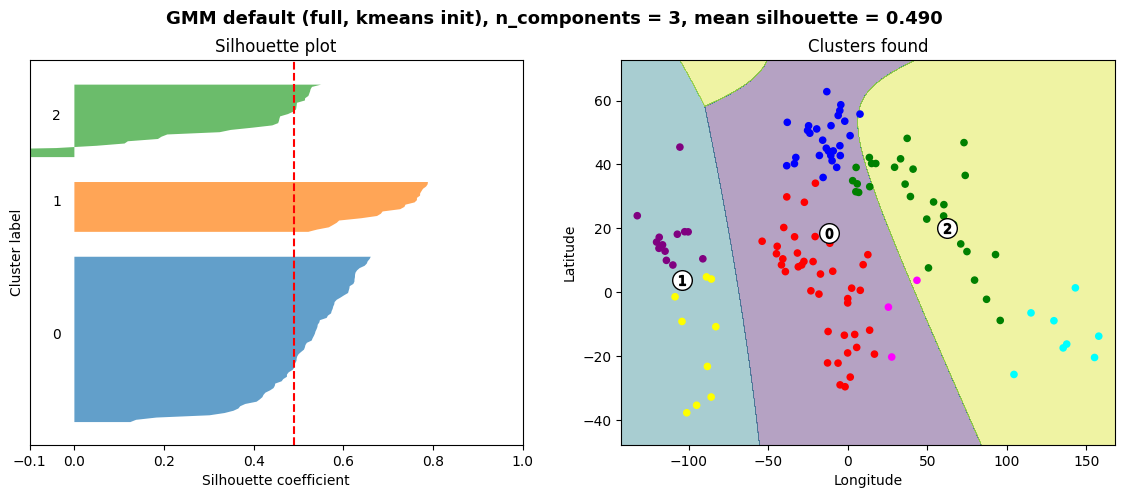

GMM default (full, kmeans init)     K=3  silhouette=0.490  BIC=2617


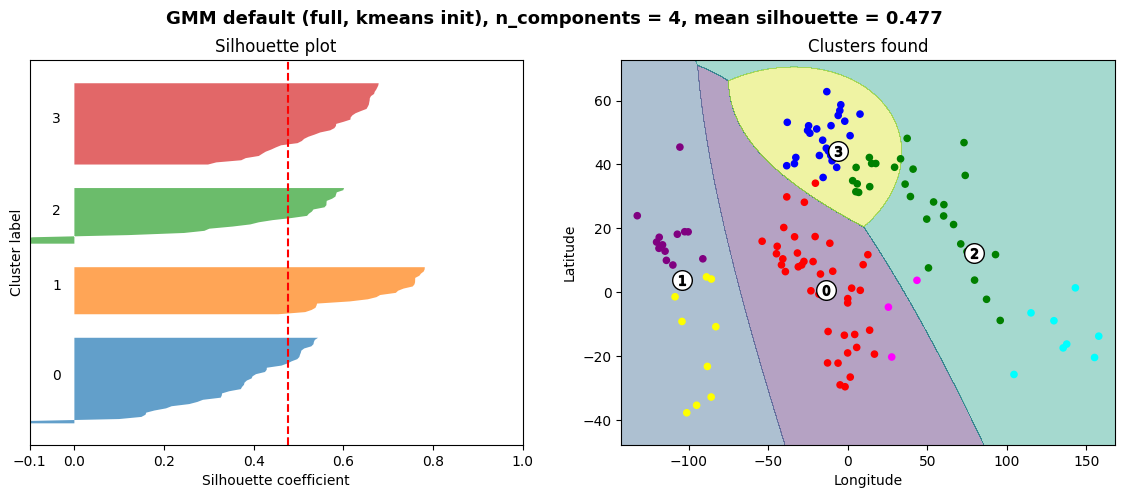

GMM default (full, kmeans init)     K=4  silhouette=0.477  BIC=2605


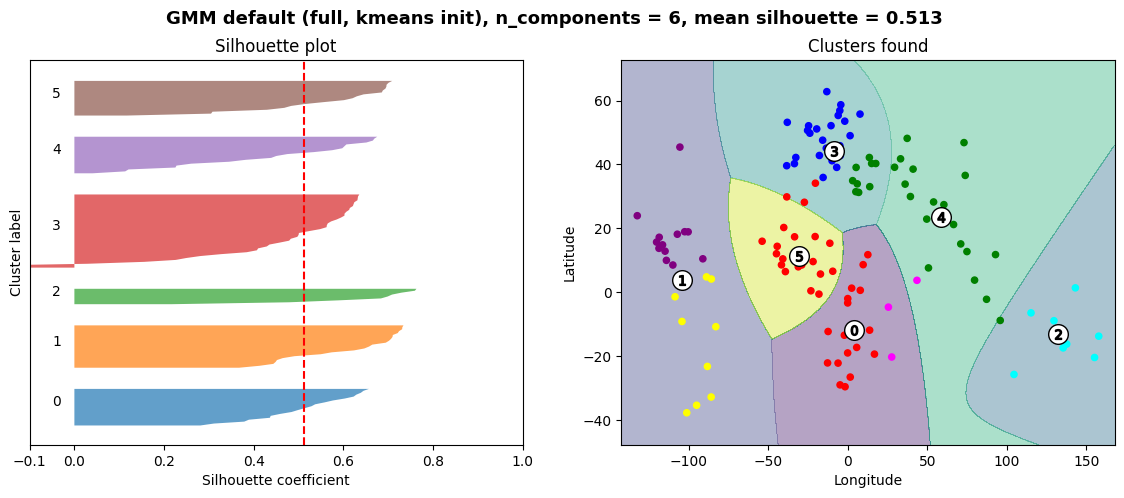

GMM default (full, kmeans init)     K=6  silhouette=0.513  BIC=2631


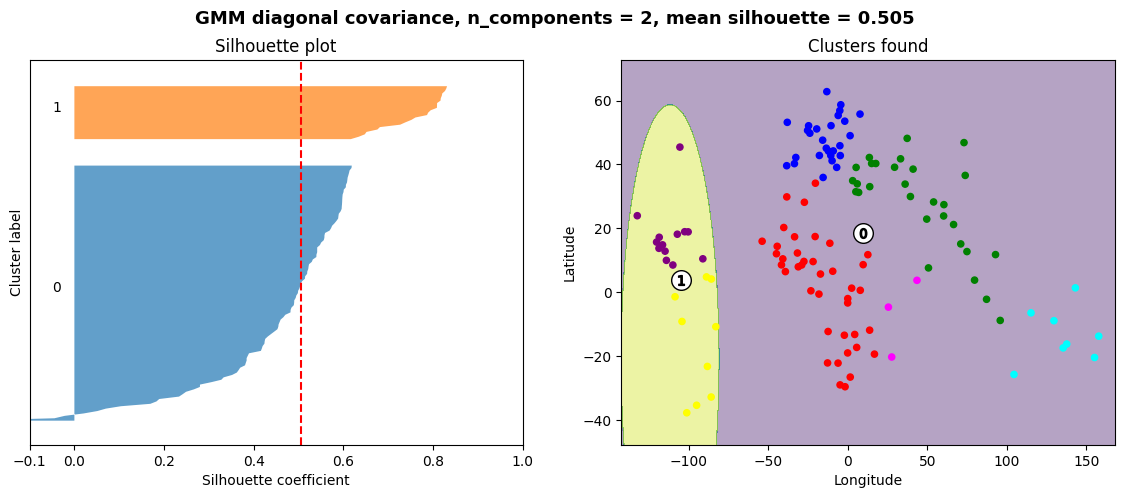

GMM diagonal covariance             K=2  silhouette=0.505  BIC=2668


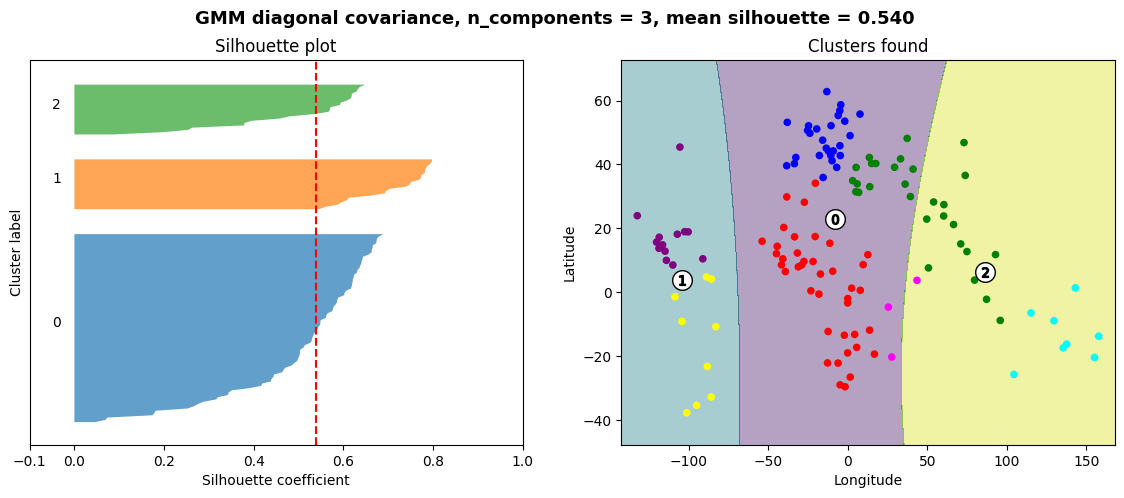

GMM diagonal covariance             K=3  silhouette=0.540  BIC=2642


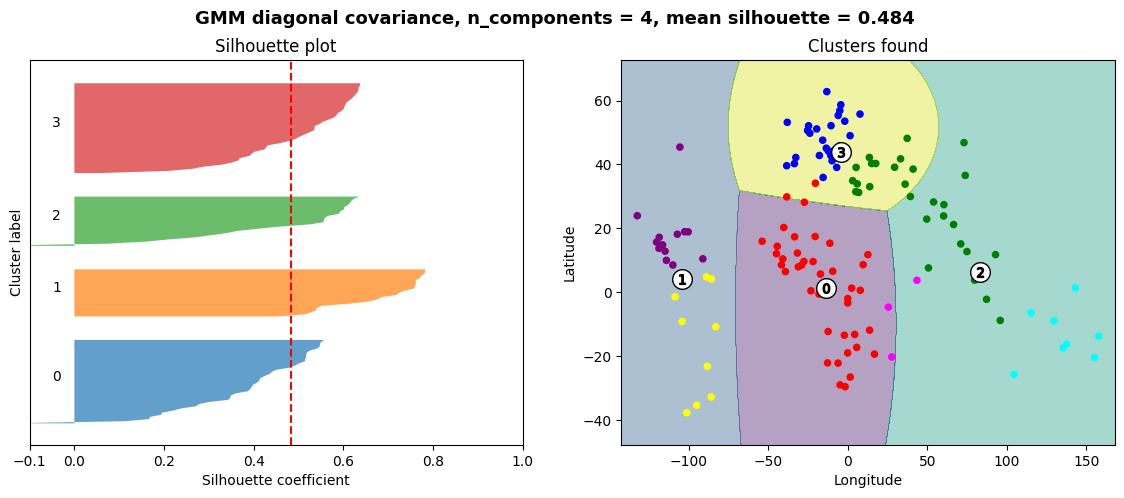

GMM diagonal covariance             K=4  silhouette=0.484  BIC=2636


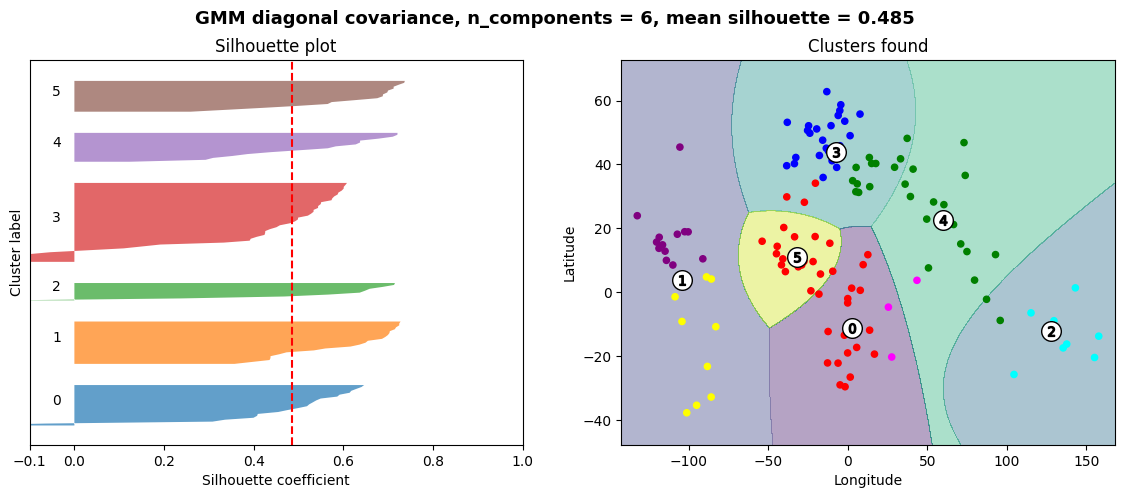

GMM diagonal covariance             K=6  silhouette=0.485  BIC=2616


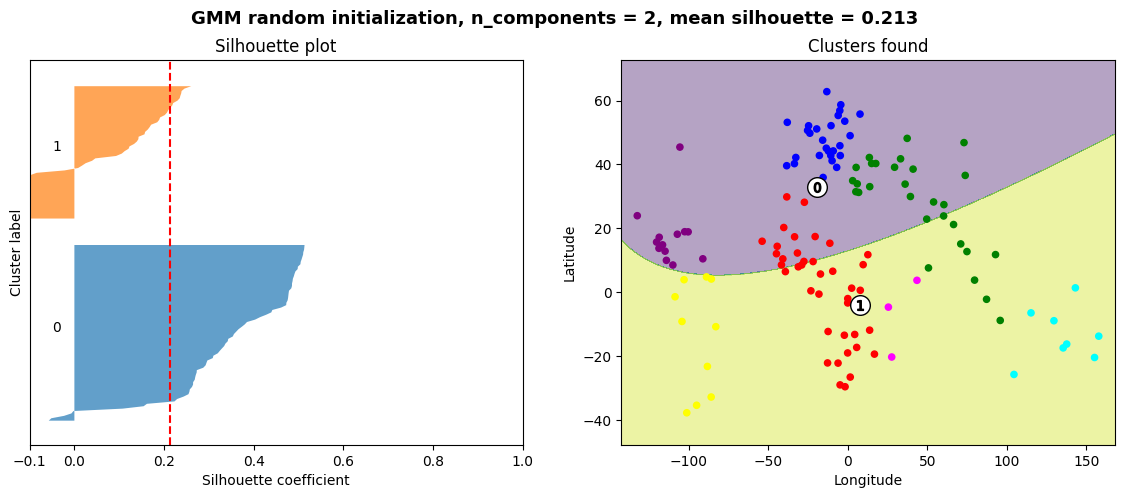

GMM random initialization           K=2  silhouette=0.213  BIC=2670


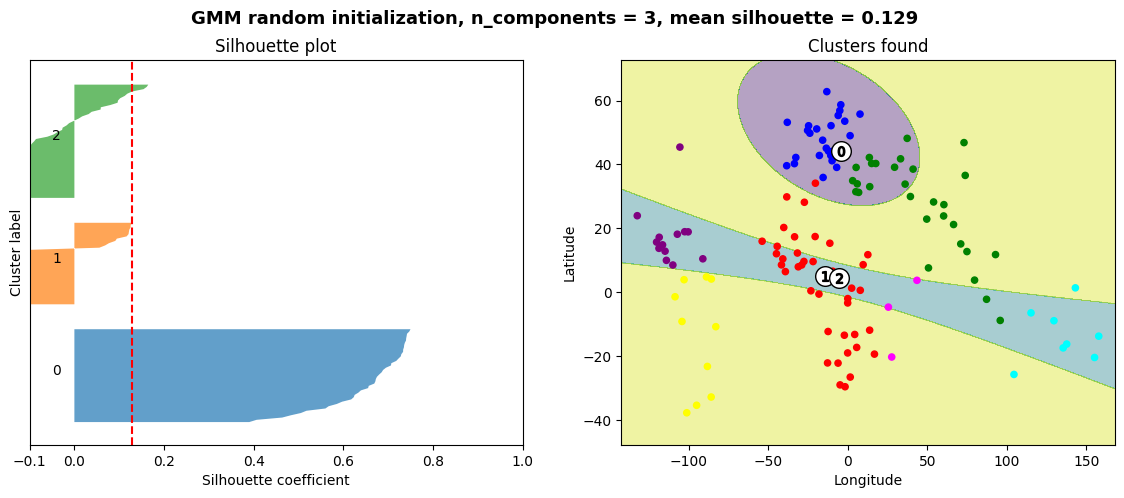

GMM random initialization           K=3  silhouette=0.129  BIC=2645


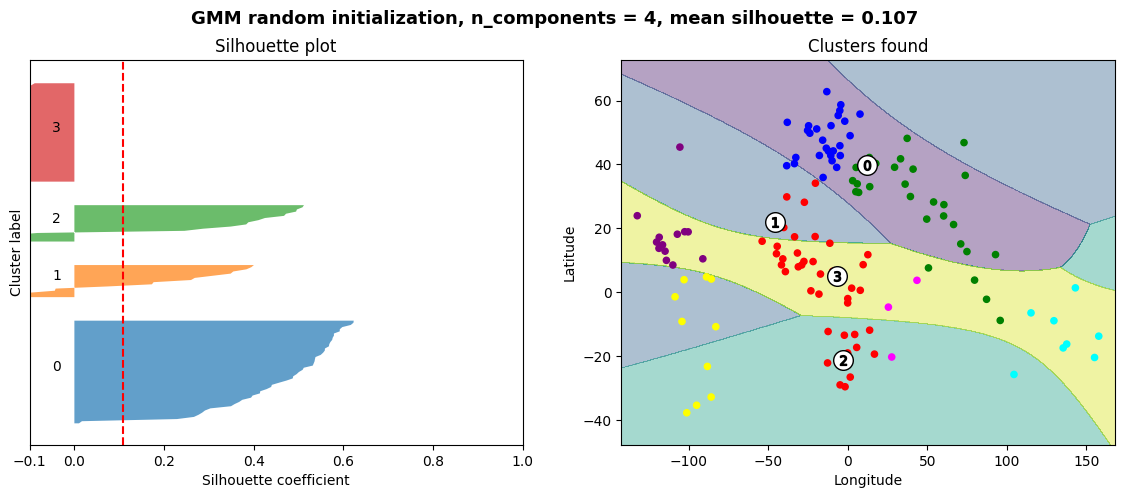

GMM random initialization           K=4  silhouette=0.107  BIC=2667


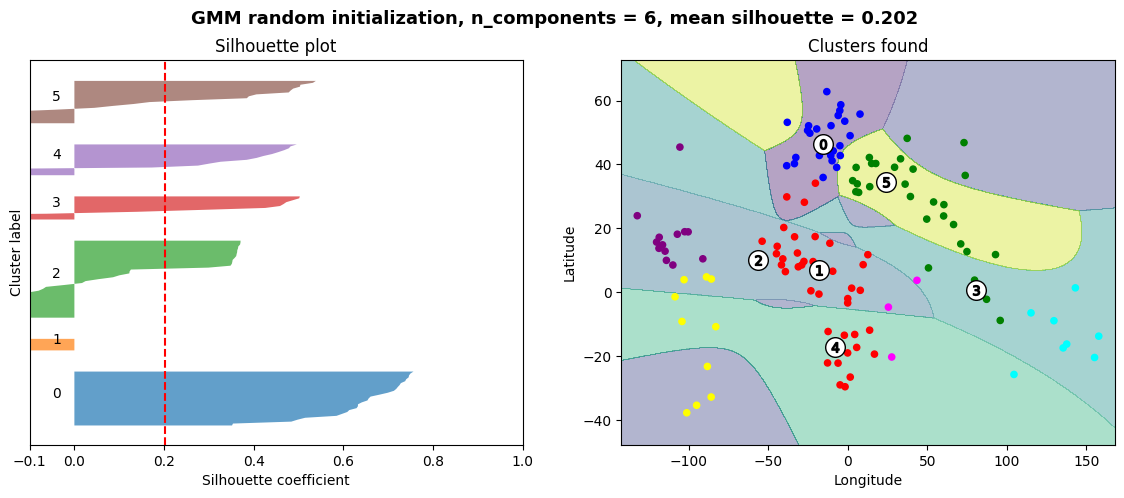

GMM random initialization           K=6  silhouette=0.202  BIC=2695
condition  GMM default (full, kmeans init)  GMM diagonal covariance  \
K                                                                     
2                                    0.492                    0.505   
3                                    0.490                    0.540   
4                                    0.477                    0.484   
6                                    0.513                    0.485   

condition  GMM random initialization  
K                                     
2                              0.213  
3                              0.129  
4                              0.107  
6                              0.202  


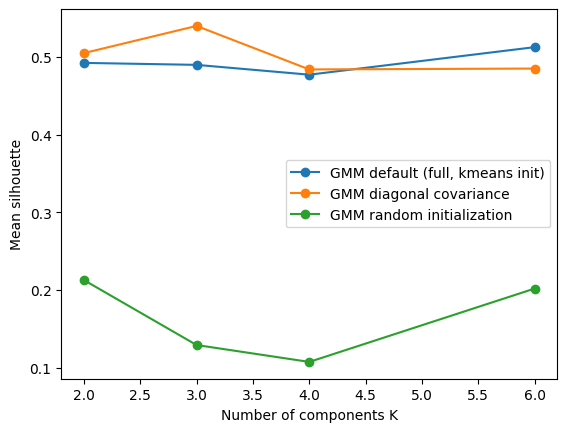

In [33]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples, silhouette_score

cmap_cont = matplotlib.colors.ListedColormap(['red', 'green', 'blue', 'purple', 'yellow', 'magenta', 'cyan'])
conditions = {
    "GMM default (full, kmeans init)": dict(),
    "GMM diagonal covariance":         dict(covariance_type='diag'),
    "GMM random initialization":       dict(init_params='random'),
}

results = []
for name, params in conditions.items():
    for K in [2, 3, 4, 6]:
        s, bic = silhouette_gmm(K, name, **params)
        results.append((name, K, s, bic))
        print(f"{name:35s} K={K}  silhouette={s:.3f}  BIC={bic:.0f}")

# Summary table and comparison curve
res = pd.DataFrame(results, columns=['condition', 'K', 'silhouette', 'BIC'])
print(res.pivot(index='K', columns='condition', values='silhouette').round(3))

for name, g in res.groupby('condition'):
    plt.plot(g.K, g.silhouette, marker='o', label=name)
plt.xlabel('Number of components K'); plt.ylabel('Mean silhouette')
plt.legend(); plt.show()

**TO CODE 4.3**

Another way to evaluate the quality of the clustering is through the homogeneity. This metric require a ground truth, so it can't be computed for every clustering problem. Luckily, we do have a ground truth here. Compute the [homogeneity score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.homogeneity_score.html "Homogeneity score") for different values of K.

method  KMeans
K             
2        0.240
3        0.425
4        0.638
5        0.709
6        0.706
7        0.834
8        0.857
10       0.875


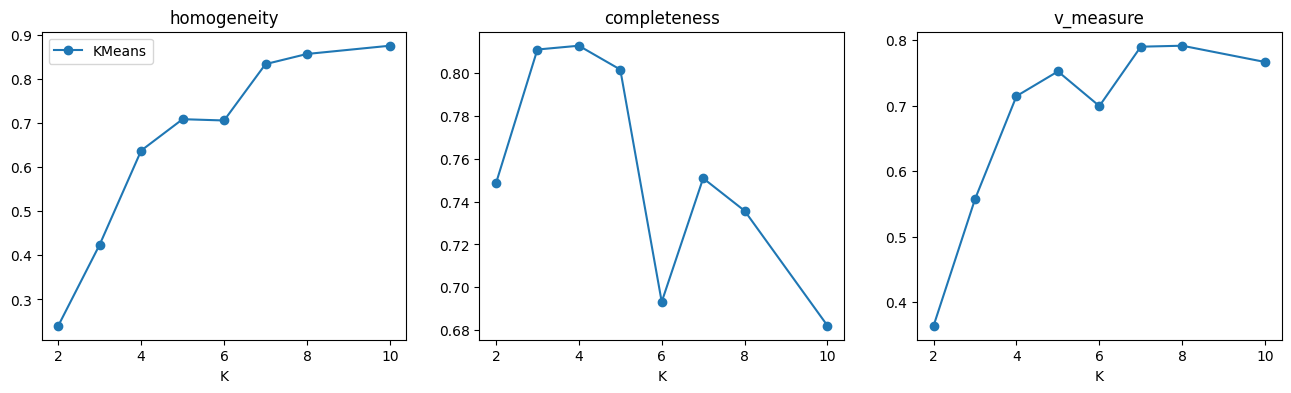

In [36]:
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score

true_labels = np_Y          # continent labels (0-6), same rows as np1
Ks = [2, 3, 4, 5, 6, 7, 8, 10]

rows = []
for K in Ks:
    km  = cluster.KMeans(n_clusters=K, n_init=10, random_state=0).fit(np1)
    for name, labels in [("KMeans", km.labels_)]:
        rows.append((name, K,
                     homogeneity_score(true_labels, labels),
                     completeness_score(true_labels, labels),
                     v_measure_score(true_labels, labels)))

res_h = pd.DataFrame(rows, columns=['method', 'K', 'homogeneity', 'completeness', 'v_measure'])
print(res_h.pivot(index='K', columns='method', values='homogeneity').round(3))

# Curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['homogeneity', 'completeness', 'v_measure']):
    for name, g in res_h.groupby('method'):
        ax.plot(g.K, g[metric], marker='o', label=name)
    ax.set_xlabel('K'); ax.set_title(metric)
axes[0].legend()
plt.show()

**Question 7**

According to the homogeneity score, which is the most relevant value of K ?\

**Answer: K=7**.\
 It is the last value where the curve still makes a big jump, and it matches the seven continents of the ground truth.\
**K=2 to 4**: homogeneity climbs fast (0.24, 0.43, 0.64).\
**K=5 to 6**: it stalls at about 0.71 (0.709, then 0.706). Adding a cluster brought nothing.\
**K=6 to 7**: it jumps again to 0.834 (+0.13). This is the last large gain.\
**K=7 to 10**: the curve flattens (0.834, 0.857, 0.875). Three extra clusters add only 0.04.\
This is the elbow of the curve, at K=7. Beyond it, you pay in complexity for very little purity.

**BONUS**
Compute the homogeneity score and analyze it for different number of components and parameters of Gaussian Mixture.

method  GMM default  GMM diag  GMM random init
K                                             
2             0.250     0.273            0.157
3             0.476     0.425            0.338
4             0.678     0.653            0.338
5             0.666     0.653            0.556
6             0.689     0.676            0.563
7             0.752     0.727            0.785
8             0.861     0.881            0.698
10            0.858     0.877            0.788


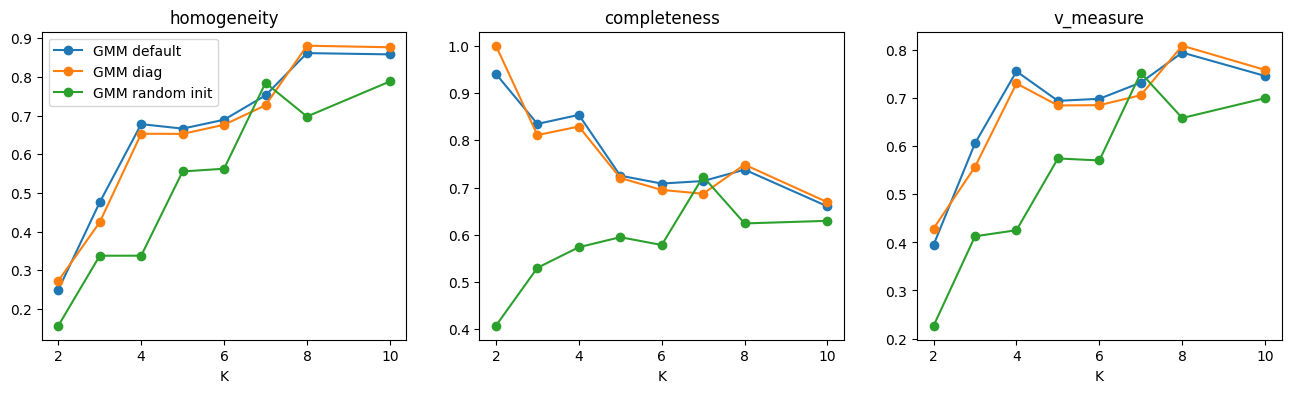

In [35]:
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score

true_labels = np_Y          # continent labels (0-6), same rows as np1
Ks = [2, 3, 4, 5, 6, 7, 8, 10]

rows = []
for K in Ks:
    gmm = GaussianMixture(n_components=K, random_state=0).fit(np1)
    gmm_diag = GaussianMixture(n_components=K, covariance_type='diag', random_state=0).fit(np1)
    gmm_rand = GaussianMixture(n_components=K, init_params='random', random_state=0).fit(np1)

    for name, labels in [
                         ("GMM default", gmm.predict(np1)),
                         ("GMM diag", gmm_diag.predict(np1)),
                         ("GMM random init", gmm_rand.predict(np1))]:
        rows.append((name, K,
                     homogeneity_score(true_labels, labels),
                     completeness_score(true_labels, labels),
                     v_measure_score(true_labels, labels)))

res_h = pd.DataFrame(rows, columns=['method', 'K', 'homogeneity', 'completeness', 'v_measure'])
print(res_h.pivot(index='K', columns='method', values='homogeneity').round(3))

# Curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['homogeneity', 'completeness', 'v_measure']):
    for name, g in res_h.groupby('method'):
        ax.plot(g.K, g[metric], marker='o', label=name)
    ax.set_xlabel('K'); ax.set_title(metric)
axes[0].legend()
plt.show()

## BONUS STEP 5: Alcoholism

This step is entirely optional and combines all the methods you used for this 3 TPs course.

The main goal is to develop a complete methodology to answer general questions.

All questions have to be justified by your homemade methodology and your methodology has also to be justified.

**QUESTION 1**

In the year 2000, which countries are heavily concerned by an Alcohol issue?

**QUESTION 2**

In these countries and in 2000, which are the parameters linked with Alcoholism? How do you explain these links?

**QUESTION 3**

Which is the evolution trend in these countries between 2000 and 2015? Try to separate these different trends.

**QUESTION 4**

By selecting a specific country, can you explain a decrease or an increase through specific policies?

In [38]:
d2000 = df[df.Year == 2000]
threshold = d2000.Alcohol.quantile(0.90)   # top 10% = heavily concerned
print(d2000[d2000.Alcohol >= threshold]
      .sort_values('Alcohol', ascending=False)[['Country', 'Alcohol']]
      .to_string(index=False))

   Country  Alcohol
    France    13.63
   Austria    13.20
Luxembourg    13.14
   Belarus    12.98
   Germany    12.91
  Portugal    11.89
   Belgium    11.21


In [39]:
d2000 = df[df.Year == 2000]
threshold = d2000.Alcohol.quantile(0.90)
high = d2000[d2000.Alcohol >= threshold]

num = d2000.select_dtypes('number').drop(columns=['Year', 'Longitude', 'Latitude'])

corr = pd.DataFrame({
    'top10% countries': high[num.columns].corr()['Alcohol'],
    'all countries':    d2000[num.columns].corr()['Alcohol'],
}).drop('Alcohol').sort_values('all countries', key=abs, ascending=False)
print(corr.round(2))

# Profile: mean of each parameter in the high group vs the others
print(pd.DataFrame({'high': high[num.columns].mean(),
                    'others': d2000[d2000.Alcohol < threshold][num.columns].mean()}).round(1))

                                 top10% countries  all countries
Schooling                                   -0.59           0.69
GDP                                          0.61           0.58
Percentage_expenditure                       0.58           0.54
Income_composition_of_resources             -0.09           0.51
Life_expectancy                             -0.01           0.41
Thinness _1-19_years                         0.28          -0.30
Polio                                       -0.17           0.30
Thinness_5-9_years                           0.30          -0.28
Adult_mortality                              0.38          -0.23
Under-five_deaths                            0.28          -0.16
Diphtheria                                  -0.12           0.16
BMI                                          0.09           0.16
Infant_deaths                                0.21          -0.16
Total_expenditure                           -0.27           0.15
Measles                  

Alcohol consumption is mostly a marker of wealth and development. Richer countries have more purchasing power, alcohol is culturally accepted (Europe), and they have better healthcare. So the link is a confounding effect of development and not a sign that alcohol improves health.

so positive links with Schooling, Income_composition_of_resources, GDP, BMI and Life_expectancy.

7 countries, years 2000 to 2014
            slope  change       trend
Country                              
France      -0.20   -2.13  decreasing
Portugal    -0.16   -2.01  decreasing
Luxembourg  -0.15   -2.02  decreasing
Germany     -0.12   -1.88  decreasing
Austria     -0.05   -0.88      stable
Belgium     -0.02    1.39      stable
Belarus      0.32    0.96  increasing
            n  slope  change
trend                       
decreasing  4  -0.16   -2.01
increasing  1   0.32    0.96
stable      2  -0.04    0.25


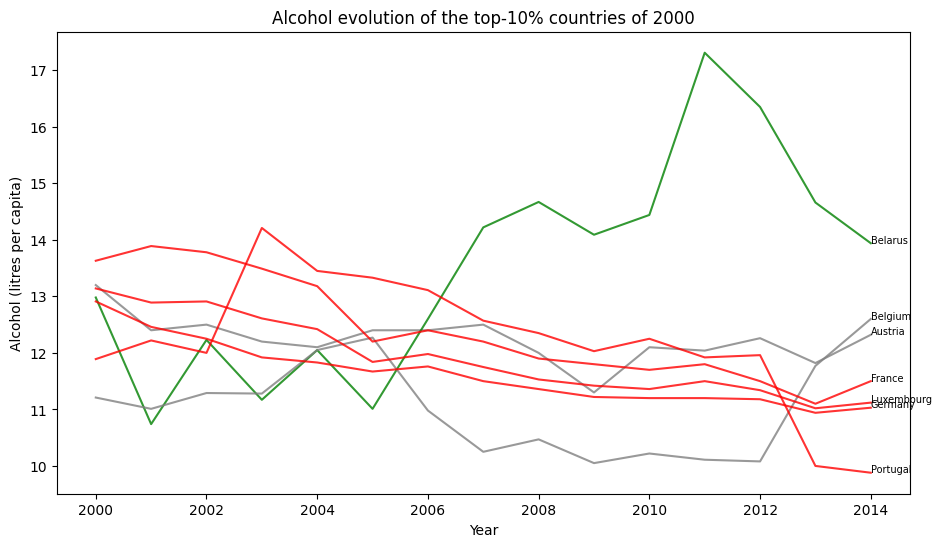

In [44]:
raw = pd.read_csv("data/Life_Expectancy_Data.csv")

d2000 = df[df.Year == 2000]
high_countries = d2000[d2000.Alcohol >= d2000.Alcohol.quantile(0.90)].Country

evo = (raw[raw.Country.isin(high_countries) & raw.Year.between(2000, 2015)]
       .dropna(subset=['Alcohol'])
       .pivot(index='Country', columns='Year', values='Alcohol')
       .dropna())

y0, y1 = evo.columns.min(), evo.columns.max()
print(len(evo), "countries, years", y0, "to", y1)

years = evo.columns.to_numpy()
slope = np.polyfit(years, evo.T.to_numpy(), 1)[0]
feat = pd.DataFrame({'slope': slope, 'change': evo[y1] - evo[y0]}, index=evo.index)

km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(feat[['slope']])
feat['trend'] = km.labels_
order = feat.groupby('trend').slope.mean().sort_values().index
feat['trend'] = feat.trend.map(dict(zip(order, ['decreasing', 'stable', 'increasing'])))

print(feat.sort_values('slope').round(2))
print(feat.groupby('trend').agg(n=('slope', 'size'), slope=('slope', 'mean'), change=('change', 'mean')).round(2))

colors = {'decreasing': 'red', 'stable': 'gray', 'increasing': 'green'}
plt.figure(figsize=(11, 6))
for c in evo.index:
    plt.plot(years, evo.loc[c], color=colors[feat.loc[c, 'trend']], alpha=0.8)
    plt.annotate(c, (years[-1], evo.loc[c, years[-1]]), fontsize=7)
plt.xlabel('Year'); plt.ylabel('Alcohol (litres per capita)')
plt.title('Alcohol evolution of the top-10% countries of 2000')
plt.show()

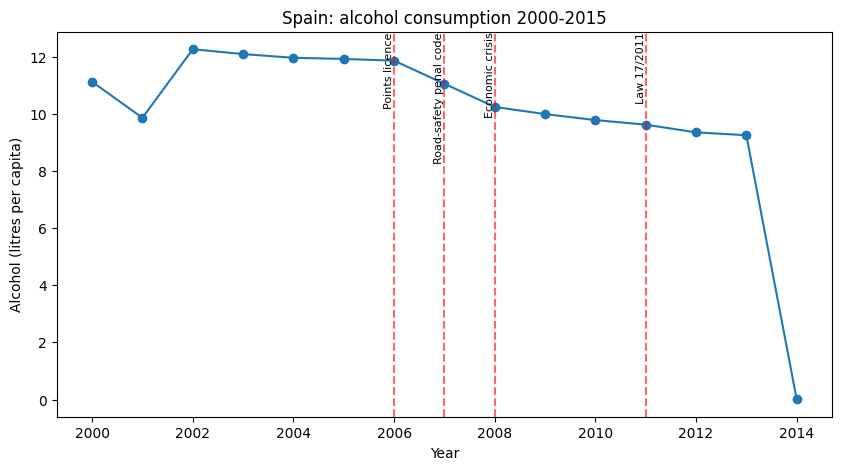

 Year  Alcohol     GDP  Adult_mortality  Life_expectancy
 2000     11.1 14676.8             86.0             79.1
 2001      9.9 15323.6             84.0             79.4
 2002     12.3  1719.5             83.0             79.5
 2003     12.1 21495.8             83.0             79.4
 2004     12.0 24918.6             79.0             81.0
 2005     11.9  2651.7             77.0             81.0
 2006     11.9 28482.7             73.0             88.0
 2007     11.0  3279.4             72.0             89.0
 2008     10.2 35578.7              7.0             81.3
 2009     10.0 32333.5             66.0             81.6
 2010      9.8  3736.2             64.0             81.9
 2011      9.6 31834.2             63.0             82.1
 2012      9.4 28562.3             61.0             82.0
 2013      9.2  2921.9              6.0             82.4
 2014      0.0   296.5             58.0             82.6
 2015      NaN 25683.8             56.0             82.8
Alcohol            1.00
GDP    

In [45]:
raw = pd.read_csv("data/Life_Expectancy_Data.csv")
sp = raw[(raw.Country == 'Spain') & raw.Year.between(2000, 2015)].sort_values('Year')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sp.Year, sp.Alcohol, marker='o')
for y, label in [(2006, 'Points licence'), (2007, 'Road-safety penal code'),
                 (2008, 'Economic crisis'), (2011, 'Law 17/2011')]:
    ax.axvline(y, color='red', ls='--', alpha=0.6)
    ax.text(y, ax.get_ylim()[1], label, rotation=90, va='top', ha='right', fontsize=8)
ax.set_xlabel('Year'); ax.set_ylabel('Alcohol (litres per capita)')
ax.set_title('Spain: alcohol consumption 2000-2015')
plt.show()

# Compare with an economic variable and with road/health outcomes
print(sp[['Year', 'Alcohol', 'GDP', 'Adult_mortality', 'Life_expectancy']].round(1).to_string(index=False))
print(sp[['Alcohol', 'GDP', 'Adult_mortality']].corr()['Alcohol'].round(2))